### Task Description:
#### Train a ML method to recognize <font color=red> Plant Species & Fe deficiency</font> based on the different hyperspectral spectra (i.e., measuring leaf reflectance at different wavelengths in the range of 400 to 1000 nm).
- In the TXT file, you will find an experiment conducted on four different species (Cs = Cucumber, Sl = Tomato, Zm = Maize, Hv = Barley) grown under Fe-deficient conditions.
- Each row refers to a different plant, while the columns indicate the values at various wavelengths of the reflectance spectrum (from 400 to 1000 nm).
- The second column contains the plant species information ("Species": Cs is cucumber, Zm is maize, Sl is tomato, Hv is barley).
- The third column contains the treatment information ("Thesis": +N-Fe indicates iron deficiency, +N+Fe indicates iron sufficiency).

#### Methods
- <font color=red> Multi-output </font> Linear Logistic Regression
- <font color=red> Multi-output </font> Polynomial Logistic Regression
- <font color=red> Multi-output </font> Random Forest

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, make_scorer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.decomposition import PCA

#### Load and Preprocess
- Drop the 'Leaf' column as it has the same value 'YL' for all rows
- Encode the <font color=red> ‘Species' and ‘Thesis' </font> column (the ground-truth label)
- Separate the dataset into features and labels
- Check class imbalance in the whole dataset
- Check for missing values (there was none)
- Identify outliers using the IQR method ---> <font color=red> I did not drop them </font>
- Feature selection using Random Forest ---> <font color=red> 87 non-important features out of 204 </font>
- Scale the feature values (here, Columns) using Z-Score

Class Distribution for Iron Deficiency:
Thesis
+N+Fe    72
+N-Fe    72
Name: count, dtype: int64


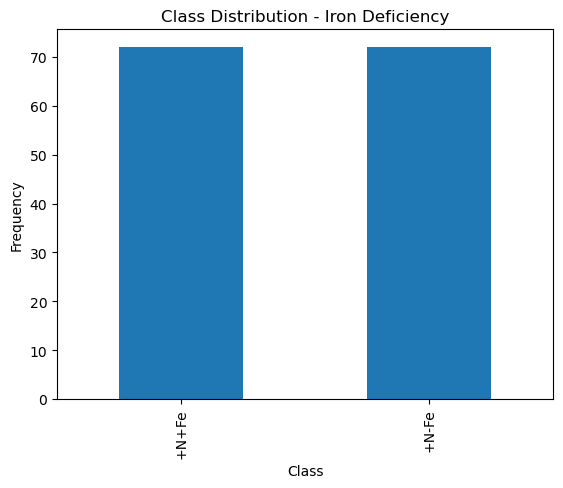

Class Distribution for Plant Type:
Species
Cs    36
Sl    36
Hv    36
Zm    36
Name: count, dtype: int64


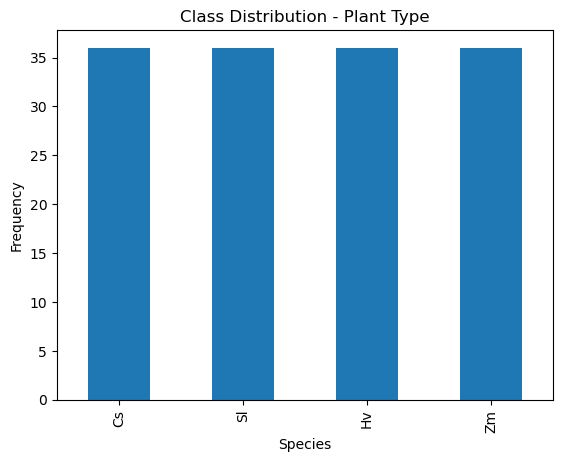

Columns with missing values: []

Outlier records/rows in the dataset:
Row numbers of outliers: [ 30  31  32  33  34  35  91  92  93  94  95  96  97  98  99 101 104 105
 106 107 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141
 142 143]

Number of features with 0.0 importance: 87
Features with 0.0 importance: ['X403.09', 'X417.52', 'X431.97', 'X434.87', 'X437.76', 'X495.89', 'X498.80', 'X504.64', 'X510.48', 'X516.33', 'X528.03', 'X551.49', 'X557.36', 'X563.24', 'X583.85', 'X592.70', 'X598.60', 'X607.46', 'X616.34', 'X619.30', 'X640.04', 'X643.01', 'X660.84', 'X666.79', 'X675.73', 'X717.54', 'X720.54', 'X726.53', 'X729.53', 'X732.53', 'X735.53', 'X747.54', 'X756.56', 'X759.56', 'X762.57', 'X765.58', 'X768.60', 'X771.61', 'X774.62', 'X777.64', 'X783.67', 'X786.68', 'X789.70', 'X792.72', 'X795.74', 'X801.79', 'X804.81', 'X807.84', 'X810.86', 'X813.89', 'X816.92', 'X822.98', 'X829.04', 'X838.14', 'X841.18', 'X847.25', 'X850.29', 'X853.33', 'X859.42', 'X862.46', 'X865.50', 'X8

In [38]:
# Load your dataset
data = pd.read_csv('Dati_HIS_Serra_Cs_Hv_Sl_Zm_no_Fe.txt', delimiter='\t')
# Drop the 'leaf' column
data = data.drop(columns=['Leaf'])

# Separate the dataset into features and labels
X = data.iloc[:, 3:]
y_iron = data['Thesis']
y_plant = data['Species']

# Encode labels
le_iron = LabelEncoder()
y_iron_encoded = le_iron.fit_transform(y_iron)
le_plant = LabelEncoder()
y_plant_encoded = le_plant.fit_transform(y_plant)

# Check class distribution for iron deficiency
class_distribution_iron = y_iron.value_counts()
print("Class Distribution for Iron Deficiency:")
print(class_distribution_iron)
# Visualize class distribution for iron deficiency
class_distribution_iron.plot(kind='bar')
plt.title('Class Distribution - Iron Deficiency')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()
# Check class distribution for plant type
class_distribution_plant = y_plant.value_counts()
print("Class Distribution for Plant Type:")
print(class_distribution_plant)
# Visualize class distribution for plant type
class_distribution_plant.plot(kind='bar')
plt.title('Class Distribution - Plant Type')
plt.xlabel('Species')
plt.ylabel('Frequency')
plt.show()
           
# Combine labels into a single DataFrame
y_combined = np.column_stack((y_iron_encoded, y_plant_encoded))


# Check for missing values
print(f"Columns with missing values: {data.columns[data.isnull().any()].tolist()}")

# Identify rows where at least one feature (column) has an outlier
print("\nOutlier records/rows in the dataset:")
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1
outliers = ((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).any(axis=1)
outlier_rows = np.where(outliers)[0]
print("Row numbers of outliers:", outlier_rows)

# Feature selection using RandomForestClassifier
rf = RandomForestClassifier(n_estimators=15, random_state=42)
rf.fit(X, y_combined)
feature_importances = pd.Series(rf.feature_importances_, index=X.columns)
zero_importance_features = feature_importances[feature_importances == 0.0].index.tolist()
print(f"\nNumber of features with 0.0 importance: {len(zero_importance_features)}")
print("Features with 0.0 importance:", zero_importance_features)
# print("\nFeature Importances:")
# print(feature_importances.sort_values(ascending=False))
# Remove zero importance features from X
# X_reduced = X.drop(columns=zero_importance_features)
# print("\nX_reduced.shape is ", X_reduced.shape)

# Scale the feature values
scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_reduced)
X_scaled = scaler.fit_transform(X)

# Extra prints for debugging
print("X_scaled is",X_scaled.shape)
# print (X_scaled)
print("y_combined is", y_combined.shape)
# print(y_combined)

print()

#### The following cell is related to "train & test" split which is under discussion
- Plan A: Blindly trust "train_test_split()" function
- Plan B: Manually, decompose the dataset based on plant type, Shuffle and Split (75% for Train and 25% for Test) Within Each Plant Species and 2) Combine the Splits
- Plan C: <font color=red> 1) Use the train_test_split function to shuffle and split the data for each plant species separately. The split is set to 75% for training and 25% for testing  each plant species has its own shuffled and split data, 2) Combine the Splits: combine the training subsets of (1) into a single training set and the test subsets into a single test set. </font>

In [ ]:
# Step 3: Train-Test Split

#Plan A
X_train, X_test, y_train_combined, y_test_combined = train_test_split(X_scaled, y_combined, test_size=0.25, random_state=42)

# # Common between plan B&C
# # Grouping the data by plant using X_scaled and y_combined
# plant_groups_scaled = {
#     "Plant1": (X_scaled[0:36], y_combined[0:36]),
#     "Plant2": (X_scaled[36:72], y_combined[36:72]),
#     "Plant3": (X_scaled[72:108], y_combined[72:108]),
#     "Plant4": (X_scaled[108:144], y_combined[108:144])
# }


# # Plan C
# X_train_list = []
# y_train_list = []
# X_test_list = []
# y_test_list = []
# # Iterate over each plant species
# for plant in plant_groups_scaled.keys():
#     X = plant_groups_scaled[plant][0]
#     y = plant_groups_scaled[plant][1]
    
#     # Split the data for each plant species (e.g., 75% train, 25% test)
#     X_train_plant, X_test_plant, y_train_plant, y_test_plant = train_test_split(X, y, test_size=0.25, shuffle=True, random_state=42)
    
#     # Append to the respective lists
#     X_train_list.append(X_train_plant)
#     y_train_list.append(y_train_plant)
#     X_test_list.append(X_test_plant)
#     y_test_list.append(y_test_plant)

# # Concatenate the lists to form the final train and test sets
# X_train = np.concatenate(X_train_list, axis=0)
# y_train_combined = np.concatenate(y_train_list, axis=0)
# X_test= np.concatenate(X_test_list, axis=0)
# y_test_combined = np.concatenate(y_test_list, axis=0)

# Confirm the shape of the train and test sets
print(f"X_train shape: {X_train.shape}, y_train_combined shape: {y_train_combined.shape}")
print(f"X_test shape: {X_test.shape}, y_test_combined shape: {y_test_combined.shape}")

# Plan C
# ...

#### Hyperparameter Tuning Using GridSearchCV , Model Training, and Evaluation
- Linear Logistic Regression </font>
- Polynomial Logistic Regression </font>
- Randomforest

- <font color=red> Crossfold Validationr in GridSearch (Hyperparameter tuning)</font>

#### <font color=green> <font color=red> Multi-Output </font>  Standard Logistic Regression </font>

Best parameters for Multi-Output Logistic Regression: {'estimator__C': 30, 'estimator__penalty': 'l2', 'estimator__solver': 'lbfgs'}

Standard Logistic Regression - Test Set Accuracy Iron Deficiency: 1.0
Iron Deficiency Prediction:
              precision    recall  f1-score   support

       +N+Fe       1.00      1.00      1.00        18
       +N-Fe       1.00      1.00      1.00        18

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


Standard Logistic Regression - Test Set Accuracy Plant Type: 0.9166666666666666

Plant Type Prediction:
              precision    recall  f1-score   support

          Cs       0.85      1.00      0.92        11
          Hv       1.00      0.88      0.93         8
          Sl       1.00      1.00      1.00         9
          Zm       0.86      0.75      0.80         8

    accuracy                           0.92        36
   macro a

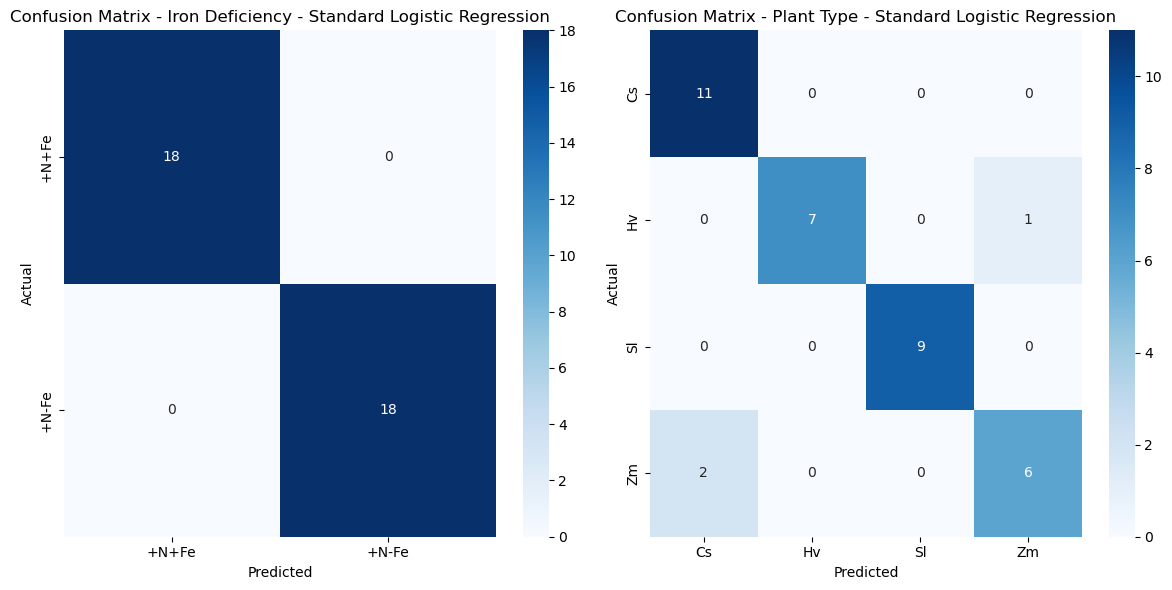

In [40]:
# Define the parameter grid for logistic regression
param_grid_lr = {
    'estimator__C': [0.01, 0.1, 1, 10, 30],
    'estimator__penalty': ['l2'],
    'estimator__solver': ['lbfgs', 'newton-cg', 'sag', 'saga']
}

# Define the Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, tol=1e-3, random_state=42)
# Create Multi-Output Classifier
multi_output_log_reg = MultiOutputClassifier(log_reg, n_jobs=-1)

# Define custom scorer
def multi_output_accuracy(y_true, y_pred):
    iron_accuracy = accuracy_score(y_true[:, 0], y_pred[:, 0])
    plant_accuracy = accuracy_score(y_true[:, 1], y_pred[:, 1])
    return (iron_accuracy + plant_accuracy) / 2

custom_scorer = make_scorer(multi_output_accuracy)

# Perform grid search
grid_search_lr = GridSearchCV(multi_output_log_reg, param_grid_lr, cv=5, scoring=custom_scorer)
grid_search_lr.fit(X_train, y_train_combined)

# Get the best parameters
best_params_lr = grid_search_lr.best_params_
print("Best parameters for Multi-Output Logistic Regression:", best_params_lr)

# Train the model with the best parameters
best_log_reg = grid_search_lr.best_estimator_
best_log_reg.fit(X_train, y_train_combined)

# Make predictions
y_pred_combined_lr = best_log_reg.predict(X_test)
y_iron_pred_lr = y_pred_combined_lr[:, 0]
y_plant_pred_lr = y_pred_combined_lr[:, 1]

# Evaluate the models
print("\nStandard Logistic Regression - Test Set Accuracy Iron Deficiency:", accuracy_score(y_test_combined[:, 0], y_iron_pred_lr))
print("Iron Deficiency Prediction:")
print(classification_report(y_test_combined[:, 0], y_iron_pred_lr, target_names=le_iron.classes_))
print("\nStandard Logistic Regression - Test Set Accuracy Plant Type:", accuracy_score(y_test_combined[:, 1], y_plant_pred_lr))
print("\nPlant Type Prediction:")
print(classification_report(y_test_combined[:, 1], y_plant_pred_lr, target_names=le_plant.classes_))

# Confusion Matrices
conf_matrix_iron = confusion_matrix(y_test_combined[:, 0], y_iron_pred_lr)
conf_matrix_plant = confusion_matrix(y_test_combined[:, 1], y_plant_pred_lr)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.heatmap(conf_matrix_iron, annot=True, fmt="d", cmap="Blues", xticklabels=le_iron.classes_, yticklabels=le_iron.classes_)
plt.title("Confusion Matrix - Iron Deficiency - Standard Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 2, 2)
sns.heatmap(conf_matrix_plant, annot=True, fmt="d", cmap="Blues", xticklabels=le_plant.classes_, yticklabels=le_plant.classes_)
plt.title("Confusion Matrix - Plant Type - Standard Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()


#### <font color=green> <font color=green> <font color=red> Multi-Output </font> Polynomial Logistic Regression </font>

Best parameters for Multi-Output Polynomial Logistic Regression: {'estimator__C': 1, 'estimator__penalty': 'l2', 'estimator__solver': 'newton-cg'}

Polynomial Logistic Regression - Test Set Accuracy Iron Deficiency: 0.9722222222222222
Iron Deficiency Prediction:
              precision    recall  f1-score   support

       +N+Fe       0.95      1.00      0.97        18
       +N-Fe       1.00      0.94      0.97        18

    accuracy                           0.97        36
   macro avg       0.97      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36


Polynomial Logistic Regression - Test Set Accuracy Plant Type: 0.9722222222222222

Plant Type Prediction:
              precision    recall  f1-score   support

          Cs       1.00      0.91      0.95        11
          Hv       1.00      1.00      1.00         8
          Sl       1.00      1.00      1.00         9
          Zm       0.89      1.00      0.94         8

    accuracy                   

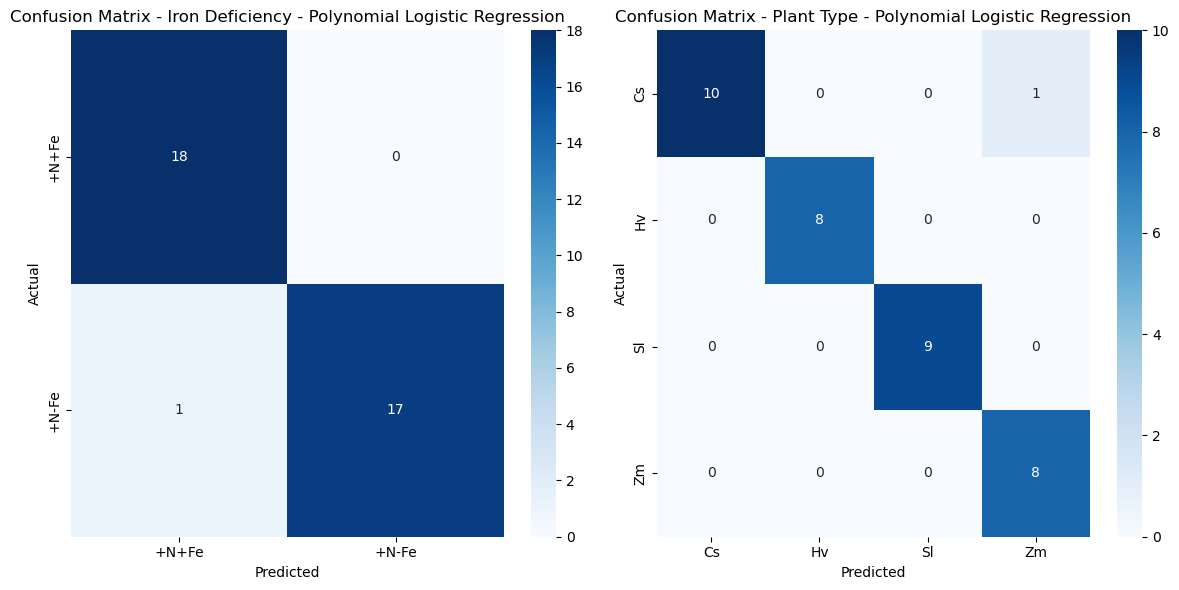

In [41]:
# Create polynomial features
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Define the parameter grid for polynomial logistic regression
param_grid_poly = {
    'estimator__C': [0.01, 0.1, 1, 10, 30],
    'estimator__penalty': ['l2'],
    'estimator__solver': ['lbfgs', 'newton-cg', 'sag', 'saga']  # Solvers that support multinomial
}

# Define the Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, tol=1e-3, random_state=42)

# Create Multi-Output Classifier
multi_output_log_reg = MultiOutputClassifier(log_reg, n_jobs=-1)

# Define custom scorer
def multi_output_accuracy(y_true, y_pred):
    iron_accuracy = accuracy_score(y_true[:, 0], y_pred[:, 0])
    plant_accuracy = accuracy_score(y_true[:, 1], y_pred[:, 1])
    return (iron_accuracy + plant_accuracy) / 2

custom_scorer = make_scorer(multi_output_accuracy)

# Perform grid search
grid_search_poly = GridSearchCV(multi_output_log_reg, param_grid_poly, cv=5, scoring=custom_scorer)
grid_search_poly.fit(X_train_poly, y_train_combined)

# Get the best parameters
best_params_poly = grid_search_poly.best_params_
print("Best parameters for Multi-Output Polynomial Logistic Regression:", best_params_poly)

# Train the model with the best parameters
best_log_reg = grid_search_poly.best_estimator_
best_log_reg.fit(X_train_poly, y_train_combined)

# Make predictions
y_pred_combined_poly = best_log_reg.predict(X_test_poly)
y_iron_pred_poly = y_pred_combined_poly[:, 0]
y_plant_pred_poly = y_pred_combined_poly[:, 1]

# Evaluate the models
print("\nPolynomial Logistic Regression - Test Set Accuracy Iron Deficiency:", accuracy_score(y_test_combined[:, 0], y_iron_pred_poly))
print("Iron Deficiency Prediction:")
print(classification_report(y_test_combined[:, 0], y_iron_pred_poly, target_names=le_iron.classes_))
print("\nPolynomial Logistic Regression - Test Set Accuracy Plant Type:", accuracy_score(y_test_combined[:, 1], y_plant_pred_poly))
print("\nPlant Type Prediction:")
print(classification_report(y_test_combined[:, 1], y_plant_pred_poly, target_names=le_plant.classes_))

# Confusion Matrices
conf_matrix_iron = confusion_matrix(y_test_combined[:, 0], y_iron_pred_poly)
conf_matrix_plant = confusion_matrix(y_test_combined[:, 1], y_plant_pred_poly)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.heatmap(conf_matrix_iron, annot=True, fmt="d", cmap="Blues", xticklabels=le_iron.classes_, yticklabels=le_iron.classes_)
plt.title("Confusion Matrix - Iron Deficiency - Polynomial Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 2, 2)
sns.heatmap(conf_matrix_plant, annot=True, fmt="d", cmap="Blues", xticklabels=le_plant.classes_, yticklabels=le_plant.classes_)
plt.title("Confusion Matrix - Plant Type - Polynomial Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

#### <font color=green> <font color=red> Multi-Output </font> Random Forest </font>

Best parameters for Multi-Output Random Forest: {'estimator__max_depth': None, 'estimator__max_features': 'sqrt', 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 2, 'estimator__n_estimators': 50}

Random Forest - Test Set Accuracy Iron Deficiency: 1.0
Iron Deficiency Prediction:
              precision    recall  f1-score   support

       +N+Fe       1.00      1.00      1.00        18
       +N-Fe       1.00      1.00      1.00        18

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


Random Forest - Test Set Accuracy Plant Type: 0.8611111111111112

Plant Type Prediction:
              precision    recall  f1-score   support

          Cs       0.91      0.91      0.91        11
          Hv       0.88      0.88      0.88         8
          Sl       0.80      0.89      0.84         9
          Zm       0.86      0.75      0.80         8

    accuracy 

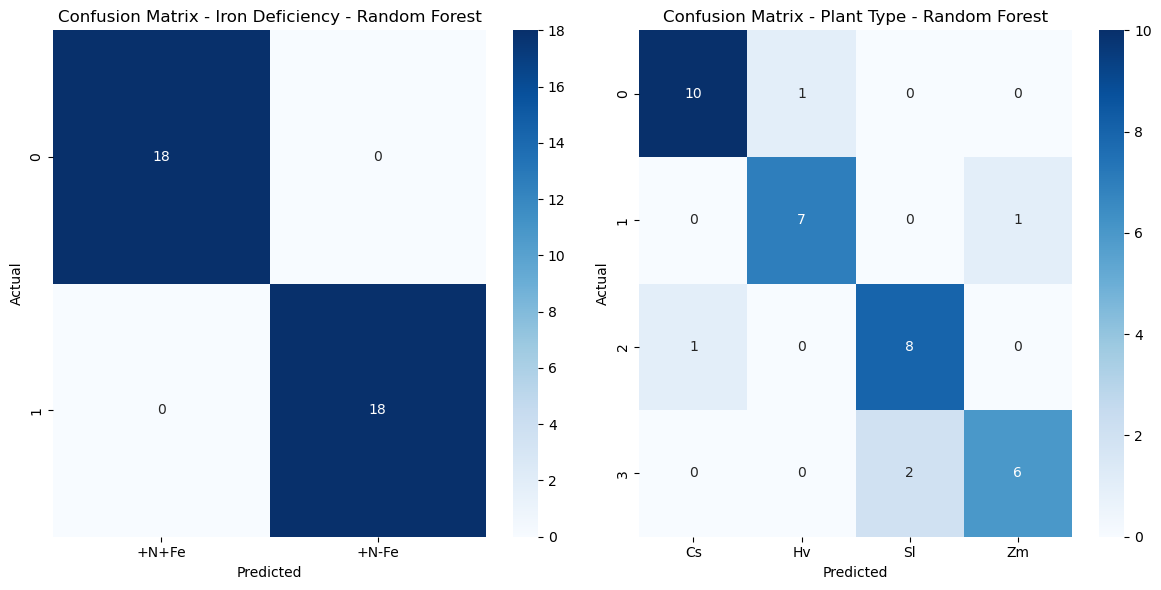

In [42]:
# Define the parameter grid
param_grid_rf = {
    'estimator__n_estimators': [10, 50, 100, 200],
    'estimator__max_depth': [None, 10, 20, 30],
    'estimator__min_samples_split': [2, 5, 10],
    'estimator__min_samples_leaf': [1, 2, 4],
    'estimator__max_features': ['sqrt', 'log2']
}

# Define the Random Forest model
forest = RandomForestClassifier(random_state=42)
multi_output_forest = MultiOutputClassifier(forest, n_jobs=-1)

# Define custom scorer
def multi_output_accuracy(y_true, y_pred):
    iron_accuracy = accuracy_score(y_true[:, 0], y_pred[:, 0])
    plant_accuracy = accuracy_score(y_true[:, 1], y_pred[:, 1])
    return (iron_accuracy + plant_accuracy) / 2

custom_scorer = make_scorer(multi_output_accuracy)

# Perform grid search
grid_search_rf = GridSearchCV(multi_output_forest, param_grid_rf, cv=5, scoring=custom_scorer)
grid_search_rf.fit(X_train, y_train_combined)

# Get the best parameters
best_params_rf = grid_search_rf.best_params_
print("Best parameters for Multi-Output Random Forest:", best_params_rf)

# Train the model with the best parameters
best_forest = grid_search_rf.best_estimator_
best_forest.fit(X_train, y_train_combined)

# Make predictions
y_pred_combined_rf = best_forest.predict(X_test)
y_iron_pred_rf = y_pred_combined_rf[:, 0]
y_plant_pred_rf = y_pred_combined_rf[:, 1]

# Evaluate the models
print("\nRandom Forest - Test Set Accuracy Iron Deficiency:", accuracy_score(y_test_combined[:, 0], y_iron_pred_rf))
print("Iron Deficiency Prediction:")
print(classification_report(y_test_combined[:, 0], y_iron_pred_rf, target_names=le_iron.classes_))
print("\nRandom Forest - Test Set Accuracy Plant Type:", accuracy_score(y_test_combined[:, 1], y_plant_pred_rf))
print("\nPlant Type Prediction:")
print(classification_report(y_test_combined[:, 1], y_plant_pred_rf, target_names=le_plant.classes_))

# Confusion Matrices
conf_matrix_iron = confusion_matrix(y_test_combined[:, 0], y_iron_pred_rf)
conf_matrix_plant = confusion_matrix(y_test_combined[:, 1], y_plant_pred_rf)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.heatmap(conf_matrix_iron, annot=True, fmt="d", cmap="Blues", xticklabels=le_iron.classes_)
plt.title("Confusion Matrix - Iron Deficiency - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 2, 2)
sns.heatmap(conf_matrix_plant, annot=True, fmt="d", cmap="Blues", xticklabels=le_plant.classes_)
plt.title("Confusion Matrix - Plant Type - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

